### Half-moon distribution with Diffusion Model 

- Diffusion Model is one of generative AI tool to learn a complex distribution by slowly destroying the complex structure by a process call adding noise. Then, it learn to reverse (a.k.a denoise) back to the complex one.

- This diffusion model is a more complex version of Gaussian Mixture Model. [TODO - understand]

- To train the diffusion model, we use a neural network to learn by minimize a KL divergence

- Some technique to accelerate the training step is to use alternative objective function which depend only on start(x_0) and end (x_T) which help us to overcome the intermediate samples.

In this notebook, the author will:

1. Implement/Train Diffusion Model from the scratch to generate Half-moon Distribution
 ![image.png](attachment:36fe46fa-307e-4f22-83a1-735064948a8c.png)
2. Accelerate the training process.
3. Try and test the code using School HPC Server. 

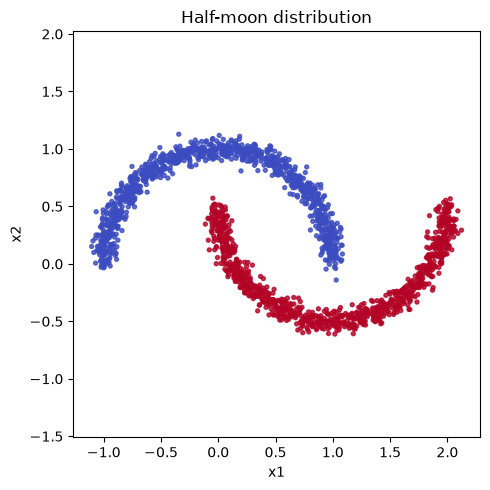

X shape: (2000, 2), y shape: (2000,)


In [1]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

n_samples = 2000
noise = 0.05
X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=8, cmap="coolwarm", alpha=0.8)
plt.title("Half-moon distribution")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.tight_layout()
plt.show()

print(f"X shape: {X.shape}, y shape: {y.shape}")


### Declare Neural Network Architecture 

In [2]:
import jax.numpy as jnp
from flax import linen as nn
import jax 

class ScoreNet(nn.Module):
    """Score network s_theta(x, t) -> R^2.
    Input: x=(x1, x2), t=time. Output: estimated score.
    """
    hidden_dim: int = 128
    n_hidden: int = 10

    @nn.compact
    def __call__(self, x, t):
        # x: (..., 2), t: (...,) or (..., 1) -> concat to (..., 3)
        t = t.reshape(x.shape[:-1] + (1,))
        h = jnp.concatenate([x, t], axis=-1)

        for _ in range(self.n_hidden):
            h = nn.Dense(self.hidden_dim)(h)
            h = nn.relu(h)

        return nn.Dense(2)(h)  # score (s1, s2)

#quick shape check
model = ScoreNet()
key = jax.random.PRNGKey(0)
x_ex = jnp.zeros((4, 2))
t_ex = jnp.zeros((4,))
params = model.init(key, x_ex, t_ex)
out = model.apply(params, x_ex, t_ex)
print("output shape:", out.shape) 

output shape: (4, 2)


In [3]:
import jax
import optax
from tqdm import trange

# hyperparameters
n_iterations = 5000
batch_size = 128
T = 1.0
epsilon = 1.0
t_min = 1e-3  # avoid division by zero when t ~ 0
lr = 1e-3

data = jnp.asarray(X)  # (N, 2)
key = jax.random.PRNGKey(0)
key, init_key = jax.random.split(key)

model = ScoreNet()
params = model.init(init_key, jnp.zeros((1, 2)), jnp.zeros((1,)))
optimizer = optax.adam(lr)
opt_state = optimizer.init(params)


def loss_fn(params, x0, t, x_t):
    # || s_theta(x_t, t) + (x_t - x0) / (t * epsilon) ||^2
    score = model.apply(params, x_t, t)
    target = (x_t - x0) / (t[:, None] * epsilon)
    return jnp.mean((score + target) ** 2)


@jax.jit
def train_step(params, opt_state, x0, key):
    key_t, key_noise = jax.random.split(key)
    t = jax.random.uniform(key_t, (x0.shape[0],), minval=t_min, maxval=T)
    # x_t ~ N(x0, t * epsilon * I)
    noise = jax.random.normal(key_noise, x0.shape)
    x_t = x0 + jnp.sqrt(t[:, None] * epsilon) * noise

    loss, grads = jax.value_and_grad(loss_fn)(params, x0, t, x_t)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


losses = []
for i in trange(n_iterations):
    key, k_batch, k_step = jax.random.split(key, 3)
    idx = jax.random.choice(k_batch, data.shape[0], shape=(batch_size,), replace=False)
    x0 = data[idx]
    params, opt_state, loss = train_step(params, opt_state, x0, k_step)
    losses.append(float(loss))
    if (i + 1) % 500 == 0:
        print(f"iter {i+1}/{n_iterations}  loss={loss:.4f}")


 11%|████▉                                       | 556/5000 [00:02<00:12, 367.52it/s]

iter 500/5000  loss=7.2530


 21%|█████████                                  | 1050/5000 [00:03<00:10, 373.52it/s]

iter 1000/5000  loss=2.2244


 31%|█████████████▎                             | 1544/5000 [00:04<00:09, 372.62it/s]

...

iter 4000/5000  loss=5.1510


 91%|███████████████████████████████████████    | 4542/5000 [00:13<00:01, 371.17it/s]

iter 4500/5000  loss=13.5598


100%|███████████████████████████████████████████| 5000/5000 [00:14<00:00, 351.03it/s]

iter 5000/5000  loss=3.2871


In [4]:
# import matplotlib.pyplot as plt 

# ax, fig = plt.plot()
# ax.plot(
#     x = [(i + 1) * 500 for i in range(len(losses))], 
#     y = losses, 
#     label = "losses"
# )
# ax.set_xlabel('no_iterations')
# ax.set_ylabel('loss')
# ax.legend()

# plt.show()

### Sample using our Neural Network

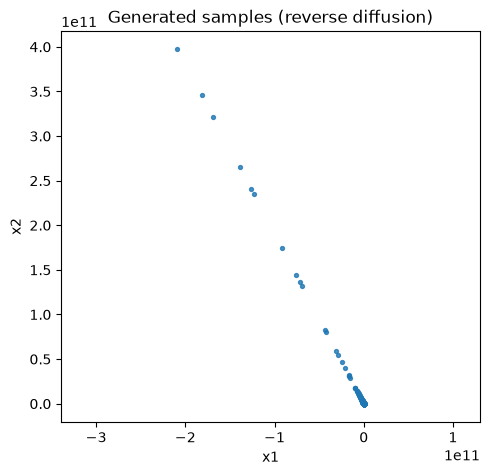

In [5]:
def generate_one(params, key, n_steps=200):
    """Reverse from x_T ~ N(0, T * epsilon * I) to one sample x_0."""
    key, k_init = jax.random.split(key)
    x = jnp.sqrt(T * epsilon) * jax.random.normal(k_init, (2,))
    dt = (T - t_min) / n_steps  # time step size while going T -> t_min

    def step(i, carry):
        x, key = carry
        key, k_noise = jax.random.split(key)
        t = T - i * dt
        score = model.apply(params, x[None, :], jnp.array([t]))[0]
        # reverse VE-SDE: dx = -epsilon * score dt + sqrt(epsilon) dW
        z = jax.random.normal(k_noise, (2,))
        x = x - epsilon * score * dt + jnp.sqrt(epsilon * dt) * z
        return x, key

    x, _ = jax.lax.fori_loop(0, n_steps, step, (x, key))
    return x


def generate_many(params, key, n_samples, n_steps=200):
    """Generate many points by vmapping generate_one."""
    keys = jax.random.split(key, n_samples)
    return jax.vmap(lambda k: generate_one(params, k, n_steps))(keys)


# test generation
key, gen_key = jax.random.split(key)
samples = generate_many(params, gen_key, n_samples=20000, n_steps=n_iterations)

plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.8)
plt.title("Generated samples (reverse diffusion)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.tight_layout()
plt.show()